# HASIL AUC UNTUK MODEL DENGAN SMOTE + TOMEK

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

HASIL AUC SKENARIO 1 DENGAN SMOTE + TOMEK
Label: ['Service Quality_negative' 'Service Quality_positive'
 'User Experience_negative' 'User Experience_positive']
AUC Service Quality_negative: 0.6515
AUC Service Quality_positive: 0.9181
AUC User Experience_negative: 0.7002
AUC User Experience_positive: 0.8678

Macro AUC: 0.7844

HASIL AUC SKENARIO 2 DENGAN SMOTE + TOMEK
Label: ['Service Quality_negative' 'Service Quality_positive'
 'User Experience_negative' 'User Experience_positive']
AUC Service Quality_negative: 0.7802
AUC Service Quality_positive: 0.9199
AUC User Experience_negative: 0.8272
AUC User Experience_positive: 0.8572

Macro AUC: 0.8461

HASIL AUC SKENARIO 3 DENGAN SMOTE + TOMEK
Label: ['Service Quality_negative' 'Service Quality_positive'
 'System Reliability_negative' 'System Reliability_positive'
 'User Experience_negative' 'User Experience_posi

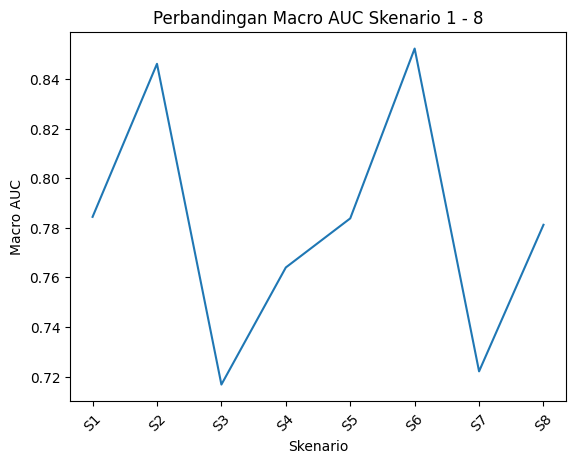


✅ Visualisasi AUC berhasil ditampilkan.


In [ ]:
# ============================================================
# HITUNG & VISUALISASI AUC UNTUK SKENARIO 1 - 8
# ============================================================

import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import roc_auc_score
from google.colab import drive
import matplotlib.pyplot as plt
import os

# Mount drive
drive.mount('/content/drive')

# Folder tempat semua file CSV berada
base_path = "/content/drive/MyDrive/SKRIPSI/DATASET/VALIDATION DATA/SMOTE TOMEK"

# Untuk menyimpan Macro AUC tiap skenario
macro_auc_results = {}

# ============================================================
# LOOP SKENARIO 1 - 8
# ============================================================

for i in range(1, 9):

    print("\n" + "="*70)
    print(f"HASIL AUC SKENARIO {i} DENGAN SMOTE + TOMEK")
    print("="*70)

    csv_path = os.path.join(base_path, f"Skenario_{i}_predictions.csv")

    if not os.path.exists(csv_path):
        print("File tidak ditemukan:", csv_path)
        continue

    # Load data
    df = pd.read_csv(csv_path)

    # Ubah string list ke list Python
    df['y_true'] = df['y_true'].apply(ast.literal_eval)
    df['y_pred'] = df['y_pred'].apply(ast.literal_eval)

    # Binarisasi
    mlb = MultiLabelBinarizer()
    y_true_bin = mlb.fit_transform(df['y_true'])
    y_pred_bin = mlb.transform(df['y_pred'])

    print("Label:", mlb.classes_)

    # ===============================
    # AUC PER LABEL
    # ===============================
    auc_per_label = {}

    for j, label in enumerate(mlb.classes_):
        try:
            auc_score = roc_auc_score(y_true_bin[:, j], y_pred_bin[:, j])
            auc_per_label[label] = auc_score
            print(f"AUC {label}: {auc_score:.4f}")
        except ValueError:
            auc_per_label[label] = None
            print(f"AUC {label}: Tidak bisa dihitung (hanya 1 kelas muncul)")

    # ===============================
    # MACRO AUC
    # ===============================
    valid_auc = [v for v in auc_per_label.values() if v is not None]

    if len(valid_auc) > 0:
        macro_auc = np.mean(valid_auc)
        macro_auc_results[f"S{i}"] = macro_auc
        print(f"\nMacro AUC: {macro_auc:.4f}")
    else:
        print("\nMacro AUC tidak dapat dihitung")

# ============================================================
# VISUALISASI (1 PLOT SAJA)
# ============================================================

if len(macro_auc_results) > 0:
    plt.figure()
    plt.plot(list(macro_auc_results.keys()),
             list(macro_auc_results.values()))
    plt.xlabel("Skenario")
    plt.ylabel("Macro AUC")
    plt.title("Perbandingan Macro AUC Skenario 1 - 8")
    plt.xticks(rotation=45)
    plt.show()

    print("\n✅ Visualisasi AUC berhasil ditampilkan.")
else:
    print("\nTidak ada data AUC yang bisa divisualisasikan.")


# HASIL AUC UNTUK MODEL TANPA SMOTE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

HASIL AUC SKENARIO 1
Label: ['Service Quality_negative' 'Service Quality_positive'
 'User Experience_negative' 'User Experience_positive']
AUC Service Quality_negative: 0.7595
AUC Service Quality_positive: 0.9114
AUC User Experience_negative: 0.8194
AUC User Experience_positive: 0.8626

Macro AUC: 0.8382

HASIL AUC SKENARIO 2
Label: ['Service Quality_negative' 'Service Quality_positive'
 'User Experience_negative' 'User Experience_positive']
AUC Service Quality_negative: 0.5435
AUC Service Quality_positive: 0.9042
AUC User Experience_negative: 0.7220
AUC User Experience_positive: 0.8511

Macro AUC: 0.7552

HASIL AUC SKENARIO 3
Label: ['Service Quality_negative' 'Service Quality_positive'
 'System Reliability_negative' 'System Reliability_positive'
 'User Experience_negative' 'User Experience_positive']
AUC Service Quality_negative: 0.7595
AUC Service Quality

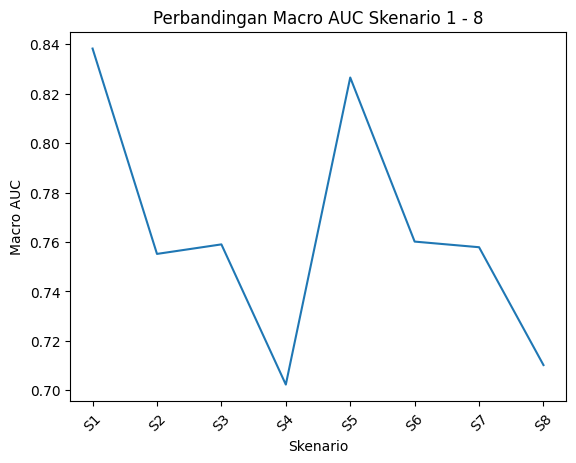


✅ Visualisasi AUC berhasil ditampilkan.


In [ ]:
# ============================================================
# HITUNG & VISUALISASI AUC UNTUK SKENARIO 1 - 8
# ============================================================

import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import roc_auc_score
from google.colab import drive
import matplotlib.pyplot as plt
import os

# Mount drive
drive.mount('/content/drive')

# Folder tempat semua file CSV berada
base_path = "/content/drive/MyDrive/SKRIPSI/DATASET/VALIDATION DATA/NON SMOTE"

# Untuk menyimpan Macro AUC tiap skenario
macro_auc_results = {}

# ============================================================
# LOOP SKENARIO 1 - 8
# ============================================================

for i in range(1, 9):

    print("\n" + "="*70)
    print(f"HASIL AUC SKENARIO {i}  TANPA SMOTE")
    print("="*70)

    csv_path = os.path.join(base_path, f"Skenario_{i}_predictions.csv")

    if not os.path.exists(csv_path):
        print("File tidak ditemukan:", csv_path)
        continue

    # Load data
    df = pd.read_csv(csv_path)

    # Ubah string list ke list Python
    df['y_true'] = df['y_true'].apply(ast.literal_eval)
    df['y_pred'] = df['y_pred'].apply(ast.literal_eval)

    # Binarisasi
    mlb = MultiLabelBinarizer()
    y_true_bin = mlb.fit_transform(df['y_true'])
    y_pred_bin = mlb.transform(df['y_pred'])

    print("Label:", mlb.classes_)

    # ===============================
    # AUC PER LABEL
    # ===============================
    auc_per_label = {}

    for j, label in enumerate(mlb.classes_):
        try:
            auc_score = roc_auc_score(y_true_bin[:, j], y_pred_bin[:, j])
            auc_per_label[label] = auc_score
            print(f"AUC {label}: {auc_score:.4f}")
        except ValueError:
            auc_per_label[label] = None
            print(f"AUC {label}: Tidak bisa dihitung (hanya 1 kelas muncul)")

    # ===============================
    # MACRO AUC
    # ===============================
    valid_auc = [v for v in auc_per_label.values() if v is not None]

    if len(valid_auc) > 0:
        macro_auc = np.mean(valid_auc)
        macro_auc_results[f"S{i}"] = macro_auc
        print(f"\nMacro AUC: {macro_auc:.4f}")
    else:
        print("\nMacro AUC tidak dapat dihitung")

# ============================================================
# VISUALISASI (1 PLOT SAJA)
# ============================================================

if len(macro_auc_results) > 0:
    plt.figure()
    plt.plot(list(macro_auc_results.keys()),
             list(macro_auc_results.values()))
    plt.xlabel("Skenario")
    plt.ylabel("Macro AUC")
    plt.title("Perbandingan Macro AUC Skenario 1 - 8")
    plt.xticks(rotation=45)
    plt.show()

    print("\n✅ Visualisasi AUC berhasil ditampilkan.")
else:
    print("\nTidak ada data AUC yang bisa divisualisasikan.")
